# Scattering rate $dR/d\omega$ — N-site lattice, massless scalar mediator

Reorganized pipeline.  The final figure is a **3 x 4 grid** (rows = approximation,
columns = DM mass):

| Row | Name | Definition |
|-----|------|------------|
| 1 | **Full structure factor** | rate from the 2nd-and-higher order part of `s_factor_nSite` **+** `calculate_rate_single_phonon_continuum` (single-phonon continuum limit, all $q$) |
| 2 | **Incoherent approximation** | rate from `s_factor_nSite_incoh` |
| 3 | **Inc + LW** | 1st order with $q<q_{BZ}$ from `calculate_rate_single_phonon_continuum_qbz` **+** 1st order with $q>q_{BZ}$ from the incoherent $S$ **+** 2nd-and-higher order from the incoherent $S$ |

> **Massless mediator.**  Converted from the massive-mediator notebook.  The
> mediator propagator $1/(q^2+m_\phi^2)$ enters only through the DM form factor,
> $|F_{\rm DM}(q)|^2 = (q_{\rm ref}/q)^4$ with
> $q_{\rm ref} = m_\chi v_0$ and $v_0 = v_{\rm disp} = 220\,{\rm km/s}$, the
> reference momentum transfer at which $\bar\sigma$ is defined.  (The massive
> case is $|F_{\rm DM}|^2 = 1$.)  Nothing in the lattice physics changes: the
> structure factors $S(q,\omega)$, the impulse approximation, the Debye-Waller
> factor, the velocity integral $\eta(v_{\rm min})$, and the kinematic $q$ and
> $\omega$ limits are all untouched.  The form factor is applied **per $q$,
> inside the $q$ integration**, in `RateCalculations.get_diff_rate_dRdomega`
> and in `calculate_integrand` (the analytic single-phonon path, which builds
> its own prefactor).  The rate is still linear in $\bar\sigma$.
>
> **Corrected in an earlier version:** `hbar`-based (not `h`-based) unit conversions,
> and $S$ normalized per Si *atom* ($a^3/8$) rather than per primitive cell
> ($a^3/4$).  Every rate is a factor $2(2\pi)^3 \approx 496$ larger than before —
> details at the end of section 0.

Notebook layout:

0. Setup & constants
1. Rate machinery (`RateCalculations`, velocity integral, Debye–Waller, kinematics)
2. Load the tabulated N-site structure factor
3. Integrators over a tabulated $S(q,\omega)$
4. Analytic single-phonon continuum rates
5. First-order $S$ and the 2nd-and-higher-order remainder
6. Compute every rate component
7. Assemble the three rows
8. Plot the 3 x 4 grid

## 0. Setup and shared constants

In [1]:
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 17,
    'figure.dpi': 200
})

In [3]:
# --- Physical constants (all energies in keV, all lengths in keV^-1) ---------
MASS_SI      = 26161e3           # silicon nucleus mass, keV
MASS_PROTON  = 938.272e3         # keV
A_LATTICE    = 2 * np.pi / 2.28  # lattice constant = 2.7558 keV^-1
                                 # (the analytic cells used the rounded value 2.756)
Q_BZ         = np.pi / A_LATTICE # Brillouin-zone edge = 1.1400 keV (was hard-coded as 1.14)
COUPLING     = 28                # coupling constant used in StructureFactor1D

# Each lattice site carries ONE Si atom (mass MASS_SI, coupling COUPLING), so the
# volume per scatterer is a^3/8, NOT the primitive-cell volume a^3/4 (which holds
# two Si atoms).  StructureFactor1D and the old analytic cells normalized to
# a^3/4, so every S computed with that convention is low by exactly this factor.
N_ATOMS_PER_PRIMITIVE = 2
OMEGA_CELL   = A_LATTICE**3 / (4 * N_ATOMS_PER_PRIMITIVE)   # volume per Si atom
S_SITE_NORM_FIX = float(N_ATOMS_PER_PRIMITIVE)              # applied to tabulated S
OMEGA_0      = 10e-6             # keV, dispersion scale
OMEGA_MAX    = 2 * OMEGA_0       # keV, top of the single-phonon band (20 micro-eV)
OMEGA_AVG    = 13.13e-6          # keV, mean phonon energy (impulse approximation)

# --- Halo / detector parameters ---------------------------------------------
C_KM_S      = 2.998e5
V_ESC       = 500 / C_KM_S
V_EARTH     = 240 / C_KM_S
V_DISP      = 220 / C_KM_S
V_MAX       = 0.00247            # = V_ESC + V_EARTH, in units of c

DENSITY_DM     = 0.3e6           # keV/cm^3
DENSITY_TARGET = 1.307e30        # keV/cm^3 (Si, 2329.6 kg/m^3)
CROSS_SECTION  = 1e-40           # cm^2
OMEGA_THRESHOLD = 1e-6           # keV detector threshold

# --- Unit conversions ---------------------------------------------------------
# hbar = c = 1.  The rate needs E/hbar and E/(hbar c), NOT the NIST "energy
# equivalent" entries E/h = 2.418e17 s^-1/keV and E/(hc) = 8.065e6 cm^-1/keV that
# were used previously -- those are smaller by 2*pi each.  Derived from
# scipy.constants so the h/hbar mix-up cannot silently come back.
from scipy import constants as _sc

_KEV_IN_J  = 1e3 * _sc.e
KEV2INVS   = _KEV_IN_J / _sc.hbar             # 1.5193e18 s^-1  per keV   (was 2.418e17)
KEV2INVCM  = _KEV_IN_J / (_sc.hbar * _sc.c) / 100   # 5.0677e7 cm^-1 per keV (was 8.065e6)
KEV2KG     = _KEV_IN_J / _sc.c**2             # 1.7827e-33 kg   per keV
YEAR2SEC   = 86400. * 365.
KEV2INVYR  = KEV2INVS * YEAR2SEC

### Unit / normalization corrections applied in this version

Two bugs in the earlier version, both of which rescale every rate by a constant:

**1. `h` vs `hbar` conversion factors.**  The code used the NIST *energy
equivalent* entries $E/h = 2.418\times10^{17}\,{\rm s^{-1}/keV}$ and
$E/hc = 8.065\times10^{6}\,{\rm cm^{-1}/keV}$.  In $\hbar = c = 1$ units the rate
needs $E/\hbar = 1.5193\times10^{18}\,{\rm s^{-1}/keV}$ and
$E/\hbar c = 5.0677\times10^{7}\,{\rm cm^{-1}/keV}$, each larger by $2\pi$.
The conversion enters the rate as ${\rm KEV2INVCM}^2 \times {\rm KEV2INVS}$ —
three powers — so every rate was low by $(2\pi)^3 \approx 248$, and any
cross-section limit derived from one was high by the same factor.

**2. Structure-factor normalization.**  $S$ was normalized to $\Omega_c = a^3/4$,
the Si primitive cell, which contains **two** atoms — but each lattice site
carries one Si atom's mass and coupling, and the rate divides by the *full* Si
mass density.  The volume per scatterer is $a^3/8$, so $S$, and hence the rate,
was low by a further factor 2.

Net effect: **every rate in this notebook is larger by $2(2\pi)^3 \approx 496$
than in the previous version.**  Each fix is applied in exactly one place — the
constants cell for the conversions, and at load/compute time for every tabulated
$S$ (`S_SITE_NORM_FIX`), including the cached `StructureFactor1D` output, which
is stored raw so the factor can never be applied twice.

In [4]:
# --- Verification of the corrected constants --------------------------------
print(f"KEV2INVS  = {KEV2INVS:.4e} s^-1/keV   (h-based value was 2.418e17,"
      f" ratio {KEV2INVS/2.418e17:.4f})")
print(f"KEV2INVCM = {KEV2INVCM:.4e} cm^-1/keV  (hc-based value was 8.065e6,"
      f" ratio {KEV2INVCM/8.065e6:.4f})")
print(f"KEV2KG    = {KEV2KG:.4e} kg/keV")
print()

# Three powers of the conversion enter the rate: KEV2INVCM^2 * KEV2INVS
unit_fix = (KEV2INVCM / 8.065e6)**2 * (KEV2INVS / 2.418e17)
print(f"rate correction from units          : (2pi)^3 = {unit_fix:.2f}")
print(f"rate correction from S normalization: {S_SITE_NORM_FIX:.1f}")
print(f"TOTAL vs the previous version       : {unit_fix * S_SITE_NORM_FIX:.1f}")
print()

# Cross-check that a^3/8 really is the volume per Si atom
hbarc_cm = 1.0 / KEV2INVCM                       # cm per keV^-1
n_atoms_from_lattice = 1.0 / (OMEGA_CELL * hbarc_cm**3)
n_atoms_from_density = DENSITY_TARGET / MASS_SI  # atoms per cm^3
print(f"Si number density from a^3/8    : {n_atoms_from_lattice:.4e} cm^-3")
print(f"Si number density from rho/m_Si : {n_atoms_from_density:.4e} cm^-3")
print(f"agreement: {n_atoms_from_lattice/n_atoms_from_density:.4f}")

KEV2INVS  = 1.5193e+18 s^-1/keV   (h-based value was 2.418e17, ratio 6.2832)
KEV2INVCM = 5.0677e+07 cm^-1/keV  (hc-based value was 8.065e6, ratio 6.2836)
KEV2KG    = 1.7827e-33 kg/keV

rate correction from units          : (2pi)^3 = 248.08
rate correction from S normalization: 2.0
TOTAL vs the previous version       : 496.2

Si number density from a^3/8    : 4.9750e+22 cm^-3
Si number density from rho/m_Si : 4.9960e+22 cm^-3
agreement: 0.9958


## 1. Rate machinery

`RateCalculations` integrates a tabulated $S(q,\omega)$ over $q$ at fixed $\omega$.
The module-level functions below duplicate the same physics in a vectorized,
class-free form; they are what the analytic single-phonon rates use.

In [5]:
class RateCalculations:
    """dR/domega at a single omega, integrating a tabulated S(q) over q.

    Massless mediator: the integrand carries the DM form factor
    |F_DM(q)|^2 = (ref_momentum / q)^4.  It varies over the integration
    variable, so it must sit INSIDE the q integral, not in the prefactor.
    """

    def __init__(self, mass_DM, omega_val, q_list, s_factor, cross_section):
        self.mass_DM = mass_DM
        self.mass_proton = MASS_PROTON
        self.density_DM = DENSITY_DM
        self.density_target = DENSITY_TARGET
        self.v_esc = V_ESC
        self.v_earth = V_EARTH
        self.v_disp = V_DISP

        # Reference momentum transfer at which sigma_bar is defined,
        # q_ref = m_chi * v_0 with v_0 = v_disp.  Sets the scale of the
        # massless-mediator form factor |F_DM(q)|^2 = (q_ref/q)^4.
        self.ref_momentum = mass_DM * self.v_disp

        # single omega, array of q
        self.omega_val = omega_val
        self.q_list = q_list
        self.s_factor = s_factor

        self.cross_section = cross_section  # cm^2
        self.v_max = self.v_esc + self.v_earth

        self.keV2InvS = KEV2INVS
        self.year2sec = YEAR2SEC
        self.keV2InvYr = KEV2INVYR
        self.keV2kg = KEV2KG
        self.keV2InvCm = KEV2INVCM

    def get_v_min(self, mass_DM, q_arr):
        return self.omega_val / q_arr + q_arr / (2 * mass_DM)

    def _inverse_mean_sol1(self, v_min):
        ratio = self.v_esc / self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio)
                                               - 2 * ratio * np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp
                        * (sp.special.erf((v_min + self.v_earth) / self.v_disp)
                           - sp.special.erf((v_min - self.v_earth) / self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))
        return self.v_disp**2 * np.pi / (2 * self.v_earth * norm_fac) * vel_integral

    def _inverse_mean_sol2(self, v_min):
        ratio = self.v_esc / self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio)
                                               - 2 * ratio * np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp
                        * (sp.special.erf(ratio)
                           - sp.special.erf((v_min - self.v_earth) / self.v_disp))
                        - 2 * (self.v_esc - v_min + self.v_earth) * np.exp(-ratio**2))
        return self.v_disp**2 * np.pi / (2 * self.v_earth * norm_fac) * vel_integral

    def get_inverse_mean_func(self, mass_DM, q_arr):
        v_min = self.get_v_min(mass_DM, q_arr)
        return np.where(v_min > (self.v_esc + self.v_earth), 0.,
                        np.where(v_min < (self.v_esc - self.v_earth),
                                 self._inverse_mean_sol1(v_min),
                                 self._inverse_mean_sol2(v_min)))

    def get_diff_rate_dRdomega(self):
        reducedMass = self.mass_DM * self.mass_proton / (self.mass_DM + self.mass_proton)
        constFactor = (self.density_DM * self.cross_section
                       / (4 * np.pi * self.density_target * self.mass_DM * reducedMass**2))
        # Massless-mediator DM form factor |F_DM(q)|^2 = (q_ref/q)^4.  Depends
        # only on q, so it is constant across omega -- but it varies across the
        # q integration below, so it is applied per-q here rather than pulled
        # out into constFactor.
        f_dm_sq = (self.ref_momentum / self.q_list)**4

        # q_list factor completes the dq integration measure
        integrand = (self.q_list * self.get_inverse_mean_func(self.mass_DM, self.q_list)
                     * self.s_factor * f_dm_sq)
        return (constFactor * sp.integrate.simpson(integrand, self.q_list)
                * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg)

In [6]:
# --- Stand-alone (vectorized) versions of the same physics -------------------

def _get_shared_params():
    ratio = V_ESC / V_DISP
    norm_fac = (V_DISP**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio)
                                      - 2 * ratio * np.exp(-ratio**2))
    return ratio, norm_fac


def inverse_mean_sol1(v_min):
    ratio, norm_fac = _get_shared_params()
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf((v_min + V_EARTH) / V_DISP)
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 4 * V_EARTH * np.exp(-ratio**2))
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral


def inverse_mean_sol2(v_min):
    ratio, norm_fac = _get_shared_params()
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf(ratio)
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 2 * (V_ESC - v_min + V_EARTH) * np.exp(-ratio**2))
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral


def get_inverse_mean_func(v_min):
    """DM velocity integral <1/v>. Accepts a float or an array (NaNs pass through)."""
    cond_zero = v_min > (V_ESC + V_EARTH)
    cond_sol1 = v_min < (V_ESC - V_EARTH)
    return np.where(cond_zero, 0.,
                    np.where(cond_sol1, inverse_mean_sol1(v_min), inverse_mean_sol2(v_min)))


def get_const_factor_value(mass_DM, cross_section=CROSS_SECTION):
    """Overall rate prefactor, already converted to [kg-yr-keV]^-1."""
    conversion_combined = (KEV2INVCM**2 * KEV2INVYR) / KEV2KG
    reduced_mass_inv_sq = ((mass_DM + MASS_PROTON)**2) / (mass_DM**2 * MASS_PROTON**2)
    static_prefactor = (DENSITY_DM * cross_section) / (4 * np.pi * DENSITY_TARGET)
    return (static_prefactor / mass_DM) * reduced_mass_inv_sq * conversion_combined


def get_DebyeWallerConst(q_value, nLattice=100, mass=MASS_SI,
                         omegaNaught=OMEGA_0, energyThreshold=OMEGA_THRESHOLD):
    """Debye-Waller exponent W(q) for the 1D N-site chain."""
    nu = np.arange(1, nLattice)
    omegaList = 2 * omegaNaught * np.sin(np.pi * nu / nLattice)
    omegaList = omegaList[omegaList >= energyThreshold]
    return (q_value**2) / (4 * mass * nLattice) * np.sum(1 / omegaList)

In [7]:
# --- Kinematics and the impulse approximation -------------------------------

def get_impulse_approx(q_list, omega, omega_avg=OMEGA_AVG):
    """Free-nucleus (impulse) limit of S(q, omega)."""
    deltasq = q_list**2 * omega_avg / (2 * MASS_SI)
    return (COUPLING**2 / OMEGA_CELL * np.sqrt(2 * np.pi / deltasq)
            * np.exp(-(omega - (q_list**2 / (2 * MASS_SI)))**2 / (2 * deltasq)))


def get_q_lim(mass_DM, omega_threshold=OMEGA_THRESHOLD):
    """Kinematically allowed [q_min, q_max] at fixed energy deposit."""
    root = np.sqrt(1 - 2 * omega_threshold / (mass_DM * V_MAX**2))
    return mass_DM * V_MAX * (1 - root), mass_DM * V_MAX * (1 + root)


def get_omega_lim(mass_DM, q):
    """Maximum energy deposit at fixed q."""
    return q * V_MAX - q**2 / (2 * mass_DM)

In [8]:
try:
    _cumtrapz = sp.integrate.cumulative_trapezoid
except AttributeError:            # scipy < 1.6
    _cumtrapz = sp.integrate.cumtrapz


def bin_arrays(x_data, y_data, num_bins=1000, x_range=None, edges=None,
               n_out=None, clip_negative=False):
    '''
    Integral-preserving bin average of a differential quantity.

        averages[k] = (1 / delta_k) * integral of y dx over bin k

    so sum(averages * bin widths) reproduces the integral of y over the binned
    range, to the accuracy of the trapezoid rule on the input grid.  This
    replaces the previous Nadaraya-Watson kernel smoother, which blurred
    neighbouring bins together and did not conserve the integral.

    Parameters
    ----------
    x_data, y_data : 1D arrays on the fine grid.
    num_bins       : number of bins across x_range.
    x_range        : (lo, hi).  Defaults to the full data range.  Pass the
                     plotted window so the bins land where they are seen.
    edges          : explicit bin edges; overrides num_bins / x_range.
    n_out          : if set, resample onto this many points with a monotone
                     cubic (PCHIP) through the bin centers.  Leave as None for
                     fine binning, where a polyline through the centers is
                     already smooth.
    clip_negative  : floor the result at zero.  Off by default: the 2nd-order
                     remainder rates can be genuinely negative and that should
                     not be hidden.

    Returns
    -------
    (binned_x, binned_y) : bin centers and their averages, or the resampled
                           curve when n_out is set.
    '''
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    order = np.argsort(x_data)
    x_data, y_data = x_data[order], y_data[order]
    y_data = np.nan_to_num(y_data, nan=0.0, posinf=0.0, neginf=0.0)

    if edges is None:
        lo, hi = (x_data[0], x_data[-1]) if x_range is None else x_range
        edges = np.linspace(lo, hi, int(num_bins) + 1)
    edges = np.asarray(edges, dtype=float)

    # Cumulative integral sampled at the bin edges.  np.interp clamps outside
    # the data range, so bins beyond the data contribute exactly zero.
    cum = _cumtrapz(y_data, x_data, initial=0.0)
    cum_at_edges = np.interp(edges, x_data, cum)

    binned_x = 0.5 * (edges[:-1] + edges[1:])
    binned_y = np.diff(cum_at_edges) / np.diff(edges)

    if n_out is not None and len(binned_x) >= 2:
        interp = sp.interpolate.PchipInterpolator(binned_x, binned_y, extrapolate=False)
        binned_x = np.linspace(binned_x[0], binned_x[-1], int(n_out))
        binned_y = interp(binned_x)

    if clip_negative:
        binned_y = np.clip(binned_y, 0.0, None)

    return binned_x, binned_y

In [9]:
def average_spectrum(omega, dRdomega, n_bins=16, omega_range=None, edges=None,
                     n_out=400, clip_negative=True):
    '''
    Coarse binned average of dR/domega, returned as a smooth curve.

    Identical method to bin_arrays -- only the defaults differ.  Few bins, so
    the bin centers are resampled with a monotone cubic (PCHIP), which passes
    through every bin average and cannot ring or overshoot into negative rate
    the way a natural cubic spline can.

    Returns (x, y) spanning the first to the last bin center.
    '''
    return bin_arrays(omega, dRdomega, num_bins=n_bins, x_range=omega_range,
                      edges=edges, n_out=n_out, clip_negative=clip_negative)

## 2. Load the tabulated N-site structure factor

`s_tot` is the full $S(q,\omega)$; `s_diag` keeps only the diagonal (incoherent)
piece.  Arrays are shaped `(len(qlist), len(omegalist))`.

In [10]:
nSiteData = np.load("nSiteSFactor_lwa_drdomega.npz")

# The stored S was normalized to the 2-atom primitive cell a^3/4 while each site
# carries a single Si atom -> multiply by S_SITE_NORM_FIX = 2.  Applied here, at
# load time, so re-running this cell stays idempotent.
s_factor_nSite       = nSiteData["s_tot"]  * S_SITE_NORM_FIX   # full S(q, omega)
s_factor_nSite_incoh = nSiteData["s_diag"] * S_SITE_NORM_FIX   # incoherent S(q, omega)
q_list_nSite         = nSiteData["qlist"]
omega_list_nSite     = nSiteData["omegalist"]

print("S shapes:", s_factor_nSite.shape, s_factor_nSite_incoh.shape)
print(f"q     range: {q_list_nSite.min():.4g} - {q_list_nSite.max():.4g} keV")
print(f"omega range: {omega_list_nSite.min()*1e6:.4g} - {omega_list_nSite.max()*1e6:.4g} meV")

S shapes: (2000, 2000) (2000, 2000)
q     range: 0.001 - 52.42 keV
omega range: 0 - 250 meV


## 3. Integrators over a tabulated $S(q,\omega)$

`calculate_rates_for_masses` integrates the tabulated $S$ over $q$ at each
$\omega$, extending the $q$ grid with the impulse approximation whenever the
kinematic $q_{max}$ runs past the end of the table.

In [11]:
def calculate_rates_for_masses(dmmasslist, q_list, omega_list,
                               s_factor_tot, s_factor_incoh,
                               cross_section=CROSS_SECTION):
    """
    dR/domega for each DM mass, from a tabulated S(q, omega).
    The q-range is extended via the impulse approximation where needed.

    Returns (rates_tot, rates_incoh), each shaped (len(dmmasslist), len(omega_list)).
    """
    rates_tot_all, rates_incoh_all = [], []
    q_max_table = np.max(q_list)

    for m_dm in dmmasslist:
        mass_rates_tot, mass_rates_incoh = [], []

        for i, omega in enumerate(omega_list):
            _, q_max_lim = get_q_lim(m_dm, omega_threshold=omega)

            if q_max_lim > q_max_table:
                # append 2000 impulse-approximation points beyond the table
                q_extra = np.linspace(q_max_table, q_max_lim, 2000)
                q_combined = np.concatenate([q_list, q_extra])
                s_extra = get_impulse_approx(q_extra, omega)
                s_tot_combined = np.concatenate([s_factor_tot[:, i], s_extra])
                s_incoh_combined = np.concatenate([s_factor_incoh[:, i], s_extra])
            else:
                q_combined = q_list
                s_tot_combined = s_factor_tot[:, i]
                s_incoh_combined = s_factor_incoh[:, i]

            calc_tot = RateCalculations(m_dm, omega, q_combined, s_tot_combined, cross_section)
            mass_rates_tot.append(calc_tot.get_diff_rate_dRdomega())

            calc_incoh = RateCalculations(m_dm, omega, q_combined, s_incoh_combined, cross_section)
            mass_rates_incoh.append(calc_incoh.get_diff_rate_dRdomega())

        rates_tot_all.append(mass_rates_tot)
        rates_incoh_all.append(mass_rates_incoh)

    return np.array(rates_tot_all), np.array(rates_incoh_all)

In [12]:
def calculate_rates_impulse_only(dmmasslist, omega_list, n_q=3000,
                                 cross_section=CROSS_SECTION):
    """
    dR/domega using ONLY the impulse approximation (reference curve).
    Uses n_q points between the kinematic q_min and q_max at each omega.
    """
    rates_all = []

    for m_dm in dmmasslist:
        mass_rates = []
        for omega in omega_list:
            # kinematically forbidden: 2*omega > m_dm * v_max^2
            if 2 * omega > m_dm * (V_MAX**2):
                mass_rates.append(0.0)
                continue

            q_min, q_max = get_q_lim(m_dm, omega_threshold=omega)
            q_list_impulse = np.linspace(q_min, q_max, n_q)
            s_factor_impulse = get_impulse_approx(q_list_impulse, omega)

            calc = RateCalculations(m_dm, omega, q_list_impulse, s_factor_impulse, cross_section)
            mass_rates.append(calc.get_diff_rate_dRdomega())

        rates_all.append(mass_rates)

    return np.array(rates_all)

## 4. Analytic single-phonon continuum rates

For the 1D chain the single-phonon delta function can be done analytically:
the $q$-integral collapses onto the roots of $\omega = \omega_{max}\sin(qa/2)$,
weighted by the 1D density of states $(2/a)/\sqrt{\omega_{max}^2-\omega^2}$.

These bypass `RateCalculations` and build their own prefactor, so
`calculate_integrand` applies the massless-mediator form factor
$(q_{\rm ref}/q)^4$ itself, evaluated at each dispersion root $q$.

* `calculate_rate_single_phonon_continuum` — **all** $q$ (sums over $\pm q_0$ and
  every reciprocal-lattice shift $n\,2\pi/a$).  This is the "single-phonon
  continuum limit" used in row 1. *(renamed from `calculate_rate_vs_mass`)*
* `calculate_rate_single_phonon_continuum_qbz` — restricted to the first
  Brillouin zone, $q < q_{BZ}$.  Used in row 3. *(renamed from
  `calculate_rate_vs_mass_qbz`)*

In [13]:
def calculate_integrand(q_2d, omg_1d, mchi, a=A_LATTICE):
    """
    Integrand evaluated on the q-roots of the single-phonon dispersion,
    excluding the density-of-states factor.

    This bypasses RateCalculations and builds its own prefactor, so the
    massless-mediator form factor (ref_momentum/q)^4 is applied here, at each
    root q of the single-phonon dispersion.

    q_2d : (n_omega, n_roots) array of roots (NaN where unphysical)
    omg_1d : (n_omega,) energies
    """
    omg_2d = omg_1d[:, np.newaxis]

    vmin = omg_2d / q_2d + q_2d / (2 * mchi)

    inv_mean_val = get_inverse_mean_func(vmin)
    const_val = get_const_factor_value(mchi)
    dwfactor = get_DebyeWallerConst(q_2d)

    # Massless-mediator DM form factor, evaluated at each root q.
    ref_momentum = mchi * V_DISP
    f_dm_sq = (ref_momentum / q_2d)**4

    term1 = q_2d * inv_mean_val * q_2d**2
    term2 = 2 * MASS_SI * omg_2d
    omega_cell = (a**3 / 4) / N_ATOMS_PER_PRIMITIVE   # volume per Si atom
    constants = 2 * np.pi * COUPLING**2 / omega_cell * const_val * np.exp(-2 * dwfactor)

    return (term1 / term2) * constants * f_dm_sq


def _single_phonon_rate(omega_list, dmmasslist, q_roots_func,
                        a=A_LATTICE, omega_max=OMEGA_MAX,
                        omega_threshold=OMEGA_THRESHOLD):
    """Shared driver: build roots, evaluate integrand, apply the 1D DOS."""
    results = np.zeros((len(dmmasslist), len(omega_list)))

    valid_mask = (omega_list > omega_threshold) & (omega_list < omega_max)
    omg_valid = omega_list[valid_mask]
    if len(omg_valid) == 0:
        return results

    q_roots = q_roots_func(omg_valid, a, omega_max)
    dos_inverse = (2 / a) / np.sqrt(omega_max**2 - omg_valid**2)

    for i, mchi in enumerate(dmmasslist):
        f_evaluated = calculate_integrand(q_roots, omg_valid, mchi, a=a)
        summed_f = np.nansum(f_evaluated, axis=1)
        drdomg_valid = summed_f * dos_inverse
        results[i, valid_mask] = np.nan_to_num(drdomg_valid, nan=0.0, posinf=0.0, neginf=0.0)

    return results


def calculate_rate_single_phonon_continuum(omega_list, dmmasslist, a=A_LATTICE,
                                           omega_max=OMEGA_MAX, n_max=50):
    """
    dR/domega in the single-phonon continuum limit, summing over ALL q:
    both branches (+/- q_0) and n_max reciprocal-lattice shifts on each side.
    (Formerly `calculate_rate_vs_mass`.)
    """
    def q_roots_func(omg_valid, a, omega_max):
        q_0 = (2 / a) * np.arcsin(omg_valid / omega_max)
        shifts = np.arange(-n_max, n_max + 1) * (2 * np.pi / a)
        q1_branch = q_0[:, np.newaxis] + shifts[np.newaxis, :]
        q2_branch = -q_0[:, np.newaxis] + shifts[np.newaxis, :]
        all_q_roots = np.concatenate((q1_branch, q2_branch), axis=1)
        return np.where(all_q_roots > 0, all_q_roots, np.nan)

    return _single_phonon_rate(omega_list, dmmasslist, q_roots_func,
                               a=a, omega_max=omega_max)


def calculate_rate_single_phonon_continuum_qbz(omega_list, dmmasslist, a=A_LATTICE,
                                               omega_max=OMEGA_MAX):
    """
    dR/domega in the single-phonon continuum limit, restricted to the first
    Brillouin zone (q < pi/a): only the q_0 root, no reciprocal-lattice shifts.
    (Formerly `calculate_rate_vs_mass_qbz`.)
    """
    def q_roots_func(omg_valid, a, omega_max):
        q_0 = (2 / a) * np.arcsin(omg_valid / omega_max)
        return q_0[:, np.newaxis]

    return _single_phonon_rate(omega_list, dmmasslist, q_roots_func,
                               a=a, omega_max=omega_max)

## 5. First-order $S$ and the 2nd-and-higher-order remainder

`StructureFactor1D` gives the exact 1st-order (single-phonon) $S(q,\omega)$ on the
same $(q,\omega)$ grid as the tabulated data, so the multiphonon remainder is

$$S^{(\geq 2)} = S^{\rm tot} - S^{(1)},\qquad
S^{(\geq 2)}_{\rm incoh} = S^{\rm tot}_{\rm incoh} - S^{(1)}_{\rm diag}.$$

The loop is slow (one `StructureFactor1D` solve per $q$ point), so the result is
cached to `firstOrderSFactor.npz`; set `RECOMPUTE_FIRST_ORDER = True` to redo it.

In [14]:
# Point this at the DIRECTORY containing StructureFactor1D.py
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection")
from StructureFactor1D import StructureFactor1D


def calc_first_order_s_factor(q_value, omegalength, nLattice, max_omega):
    """First-order (single-phonon) S(q, omega), binned onto the omega grid."""
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=COUPLING)
    xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True)

    sFacCalc.setup_DoS(max_omega, nBins=1000)
    sFacCalc.init_recursion(print_message=False)

    s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)

    return s_diag, s_diag + s_offdiag   # (diagonal only, total)

In [15]:
RECOMPUTE_FIRST_ORDER = False
FIRST_ORDER_CACHE = "firstOrderSFactor.npz"

omegalength = len(omega_list_nSite)
max_omega = 250e-6
nLattice = 100

# Sanity check: the 1st-order grid must match the tabulated grid, otherwise the
# subtraction below is meaningless.
qscale = np.sqrt(2 * MASS_SI * OMEGA_AVG)
qlist_expected = np.geomspace(0.001, 2 * qscale, len(q_list_nSite))
if not np.allclose(qlist_expected, q_list_nSite, rtol=1e-6):
    print("WARNING: q_list_nSite differs from the geomspace grid assumed previously.")
if not np.allclose(np.linspace(0, max_omega, omegalength), omega_list_nSite, rtol=1e-6):
    print("WARNING: omega_list_nSite differs from linspace(0, max_omega, omegalength).")

try:
    if RECOMPUTE_FIRST_ORDER:
        raise FileNotFoundError
    _cache = np.load(FIRST_ORDER_CACHE)
    _s_diag_1st_raw, _s_tot_1st_raw = _cache["s_diag_1st"], _cache["s_tot_1st"]
    print(f"Loaded first-order S from {FIRST_ORDER_CACHE}")
except FileNotFoundError:
    res_diag, res_tot = [], []
    for idx, q in enumerate(q_list_nSite):
        if idx % 100 == 0:
            print(f"Processing q-point {idx}/{len(q_list_nSite)}...")
        s_diag, s_tot = calc_first_order_s_factor(q, omegalength, nLattice, max_omega)
        res_diag.append(s_diag)
        res_tot.append(s_tot)

    _s_diag_1st_raw = np.array(res_diag)   # (n_q, n_omega), diagonal / incoherent
    _s_tot_1st_raw = np.array(res_tot)     # (n_q, n_omega), total
    np.savez(FIRST_ORDER_CACHE, s_diag_1st=_s_diag_1st_raw, s_tot_1st=_s_tot_1st_raw)
    print(f"Saved first-order S to {FIRST_ORDER_CACHE}")

# Same a^3/4 -> a^3/8 site-normalization fix as the tabulated S.  The cache holds
# the RAW StructureFactor1D output, so the factor is applied exactly once here.
finalresdiag_1st = _s_diag_1st_raw * S_SITE_NORM_FIX
finalres_1st     = _s_tot_1st_raw  * S_SITE_NORM_FIX

# 2nd-and-higher-order remainders
s_factor_nSite_2nd       = s_factor_nSite - finalres_1st
s_factor_nSite_incoh_2nd = s_factor_nSite_incoh - finalresdiag_1st

Loaded first-order S from firstOrderSFactor.npz


## 6. Compute every rate component

| variable | meaning |
|---|---|
| `dRdomega_result_2nd_4plot` | 2nd-and-higher order, full $S$ |
| `dRdomega_result_incoh_2nd_4plot` | 2nd-and-higher order, incoherent $S$ |
| `dRdomega_result_incoh_1st_4plot` | 1st order, incoherent $S$, restricted to $q>q_{BZ}$ |
| `dRdomega_result_incoh_4plot` | full incoherent rate (all orders) |
| `drdomg_sp_continuum` | analytic single-phonon continuum, all $q$ |
| `drdomg_sp_continuum_qbz` | analytic single-phonon continuum, $q<q_{BZ}$ |
| `dRdomega_impulse_tot` | impulse-approximation reference curve |

In [16]:
dmmasslist_4plot = np.array([1e2, 3e2, 1e3, 10e3])   # keV

In [17]:
# --- Full incoherent rate (row 2), plus the full-S rate for reference --------
dRdomega_result_4plot, dRdomega_result_incoh_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite, omega_list_nSite,
    s_factor_nSite, s_factor_nSite_incoh
)

In [18]:
# --- 2nd-and-higher order contributions -------------------------------------
dRdomega_result_2nd_4plot, dRdomega_result_incoh_2nd_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite, omega_list_nSite,
    s_factor_nSite_2nd, s_factor_nSite_incoh_2nd
)

In [19]:
# --- 1st order, integrated only over q > q_BZ -------------------------------
mask_qbz = q_list_nSite > Q_BZ
dRdomega_result_1st_4plot, dRdomega_result_incoh_1st_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite[mask_qbz], omega_list_nSite,
    finalres_1st[mask_qbz], finalresdiag_1st[mask_qbz]
)

In [20]:
# --- Analytic single-phonon continuum rates ---------------------------------
drdomg_sp_continuum     = calculate_rate_single_phonon_continuum(omega_list_nSite, dmmasslist_4plot)
drdomg_sp_continuum_qbz = calculate_rate_single_phonon_continuum_qbz(omega_list_nSite, dmmasslist_4plot)

In [21]:
# --- Impulse-approximation reference curve ----------------------------------
dRdomega_impulse_tot = calculate_rates_impulse_only(dmmasslist_4plot, omega_list_nSite)

C:\Users\xylin\AppData\Local\Temp\ipykernel_38124\2628970060.py:6: RuntimeWarning: divide by zero encountered in divide
  return (COUPLING**2 / OMEGA_CELL * np.sqrt(2 * np.pi / deltasq)
C:\Users\xylin\AppData\Local\Temp\ipykernel_38124\2628970060.py:7: RuntimeWarning: invalid value encountered in divide
  * np.exp(-(omega - (q_list**2 / (2 * MASS_SI)))**2 / (2 * deltasq)))
C:\Users\xylin\AppData\Local\Temp\ipykernel_38124\1106692812.py:75: RuntimeWarning: divide by zero encountered in divide
  f_dm_sq = (self.ref_momentum / self.q_list)**4
C:\Users\xylin\AppData\Local\Temp\ipykernel_38124\1106692812.py:38: RuntimeWarning: invalid value encountered in divide
  return self.omega_val / q_arr + q_arr / (2 * mass_DM)


## 7. Assemble the three rows

In [22]:
# Row 1 - full structure factor:
#   2nd-and-higher order from the full S  +  single-phonon continuum (all q)
rates_full = dRdomega_result_2nd_4plot + drdomg_sp_continuum

# Row 2 - incoherent approximation:
#   everything from s_factor_nSite_incoh
rates_incoh = dRdomega_result_incoh_4plot

# Row 3 - Inc + LW:
#   1st order, q < q_BZ  -> analytic single-phonon continuum in the 1st BZ
#   1st order, q > q_BZ  -> incoherent S
#   2nd and higher order -> incoherent S
rates_inc_lw = (drdomg_sp_continuum_qbz
                + dRdomega_result_incoh_1st_4plot
                + dRdomega_result_incoh_2nd_4plot)

for name, arr in [("rates_full", rates_full), ("rates_incoh", rates_incoh),
                  ("rates_inc_lw", rates_inc_lw)]:
    print(f"{name:14s} {arr.shape}")

rates_full     (4, 2000)
rates_incoh    (4, 2000)
rates_inc_lw   (4, 2000)


## 8. The 3 x 4 figure

In [23]:
ROW_LABELS = ["Full Structure Factor", "       Incoherent\nApproximation", "         Inc + LW\nApproximation"]
ROW_COLORS = ["tab:blue", "tab:orange", "tab:green"]


def plot_rate_grid_3x4(dmmasslist, omega_list, row_data,
                       dRdomega_impulse_tot=None,
                       row_labels=ROW_LABELS, row_colors=ROW_COLORS,
                       xmax_list=None, ylim_list=None,
                       smooth_cols=(2, 3), n_bins_smooth=250,
                       overlay_rows=(1,), overlay_cols=(0, 1),
                       overlay_colors=("yellow", "cyan"), n_bins_avg=16,
                       avg_range_list=None,
                       label_positions=None, suptitle="Massless Mediator"):
    """
    3 rows (approximation) x 4 columns (DM mass).

    row_data      : list of three (n_mass, n_omega) arrays, top row first.
    smooth_cols   : columns whose curves are kernel-smoothed before plotting.
    overlay_*     : integral-preserving binned average (average_spectrum) drawn
                    as a smooth curve on top of the raw curve.  By default only the
                    incoherent row (row 1) gets it, in the un-smoothed low-mass
                    columns.  n_bins_avg bins span the PLOTTED omega window
                    (from xmax_list), or avg_range_list[col] if given.
    """
    n_rows, n_cols = 3, 4
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 10), sharex=False)

    # Row labels are placed in AXES FRACTION coordinates (0-1), not data
    # coordinates.  The massless-mediator (q_ref/q)^4 factor rescales the y
    # axis by orders of magnitude and differently for each mass, so the old
    # hard-coded data positions would have thrown the labels off-panel.
    if label_positions is None:
        label_positions = [(0.28, 0.84), (0.44, 0.72), (0.44, 0.72)]

    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            m_dm = dmmasslist[col_idx]
            y = row_data[row_idx][col_idx]

            # --- main curve ---
            if col_idx in smooth_cols:
                binned_omega, binned_rate = bin_arrays(omega_list, y, n_bins_smooth)
                ax.plot(binned_omega * 1e6, binned_rate, color=row_colors[row_idx], linewidth=2)
            else:
                ax.plot(omega_list * 1e6, y, color=row_colors[row_idx], linewidth=2)

            # --- binned average overlay (incoherent row only) ---
            # Bins span the PLOTTED window, not the whole omega array, and the
            # average is integral-preserving -- see average_spectrum.
            if row_idx in overlay_rows and col_idx in overlay_cols:
                if avg_range_list is not None:
                    avg_lo, avg_hi = avg_range_list[col_idx]
                elif xmax_list is not None and len(xmax_list) == n_cols:
                    avg_lo, avg_hi = 0.0, xmax_list[col_idx] * 1e-6
                else:
                    avg_lo, avg_hi = omega_list.min(), omega_list.max()

                avg_omega, avg_rate = average_spectrum(omega_list, y, n_bins=n_bins_avg,
                                                       omega_range=(avg_lo, avg_hi))
                overlay_color = overlay_colors[overlay_rows.index(row_idx) % len(overlay_colors)]
                overlay_label = "Averaged" if col_idx == overlay_cols[-1] else None
                ax.plot(avg_omega * 1e6, avg_rate, color=overlay_color, lw=2,
                        label=overlay_label, zorder=5)

            # --- impulse-approximation reference ---
            if dRdomega_impulse_tot is not None:
                ia_label = "Impulse Approximation" if (row_idx == 0 and col_idx == 0) else None
                ax.plot(omega_list * 1e6, dRdomega_impulse_tot[col_idx],
                        color="lightgray", linestyle="--", label=ia_label)

            # --- formatting ---
            if row_idx == 0:
                ax.set_title(rf'$m_\chi$ = {m_dm/1000:g} MeV', fontsize=22)
            if col_idx == 0:
                ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')
            if col_idx == n_cols - 1:
                ax.yaxis.set_label_position("right")

            if row_idx == n_rows - 1:
                ax.set_xlabel('$\\omega$ [meV]')
            else:
                ax.tick_params(labelbottom=False)

            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

            if xmax_list is not None and len(xmax_list) == n_cols:
                ax.set_xlim(0, xmax_list[col_idx])
            else:
                ax.set_xlim(0, 200)

            if ylim_list is not None and len(ylim_list) == n_cols:
                ax.set_ylim(ylim_list[col_idx][0], ylim_list[col_idx][1])

    # --- legends and row labels ---
    axes[0, 0].legend(loc="center right", bbox_to_anchor=(1, 0.7))
    for row_idx in overlay_rows:
        axes[row_idx, overlay_cols[-1]].legend()

    fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.08, wspace=0.15, hspace=0.15)

    for row_idx in range(n_rows):
        x_txt, y_txt = label_positions[row_idx]
        axes[row_idx, 0].text(x_txt, y_txt, row_labels[row_idx],
                              transform=axes[row_idx, 0].transAxes,
                              fontsize=22, color=row_colors[row_idx])

    plt.suptitle(suptitle, fontsize=26, y=1)
    plt.show()
    return fig, axes

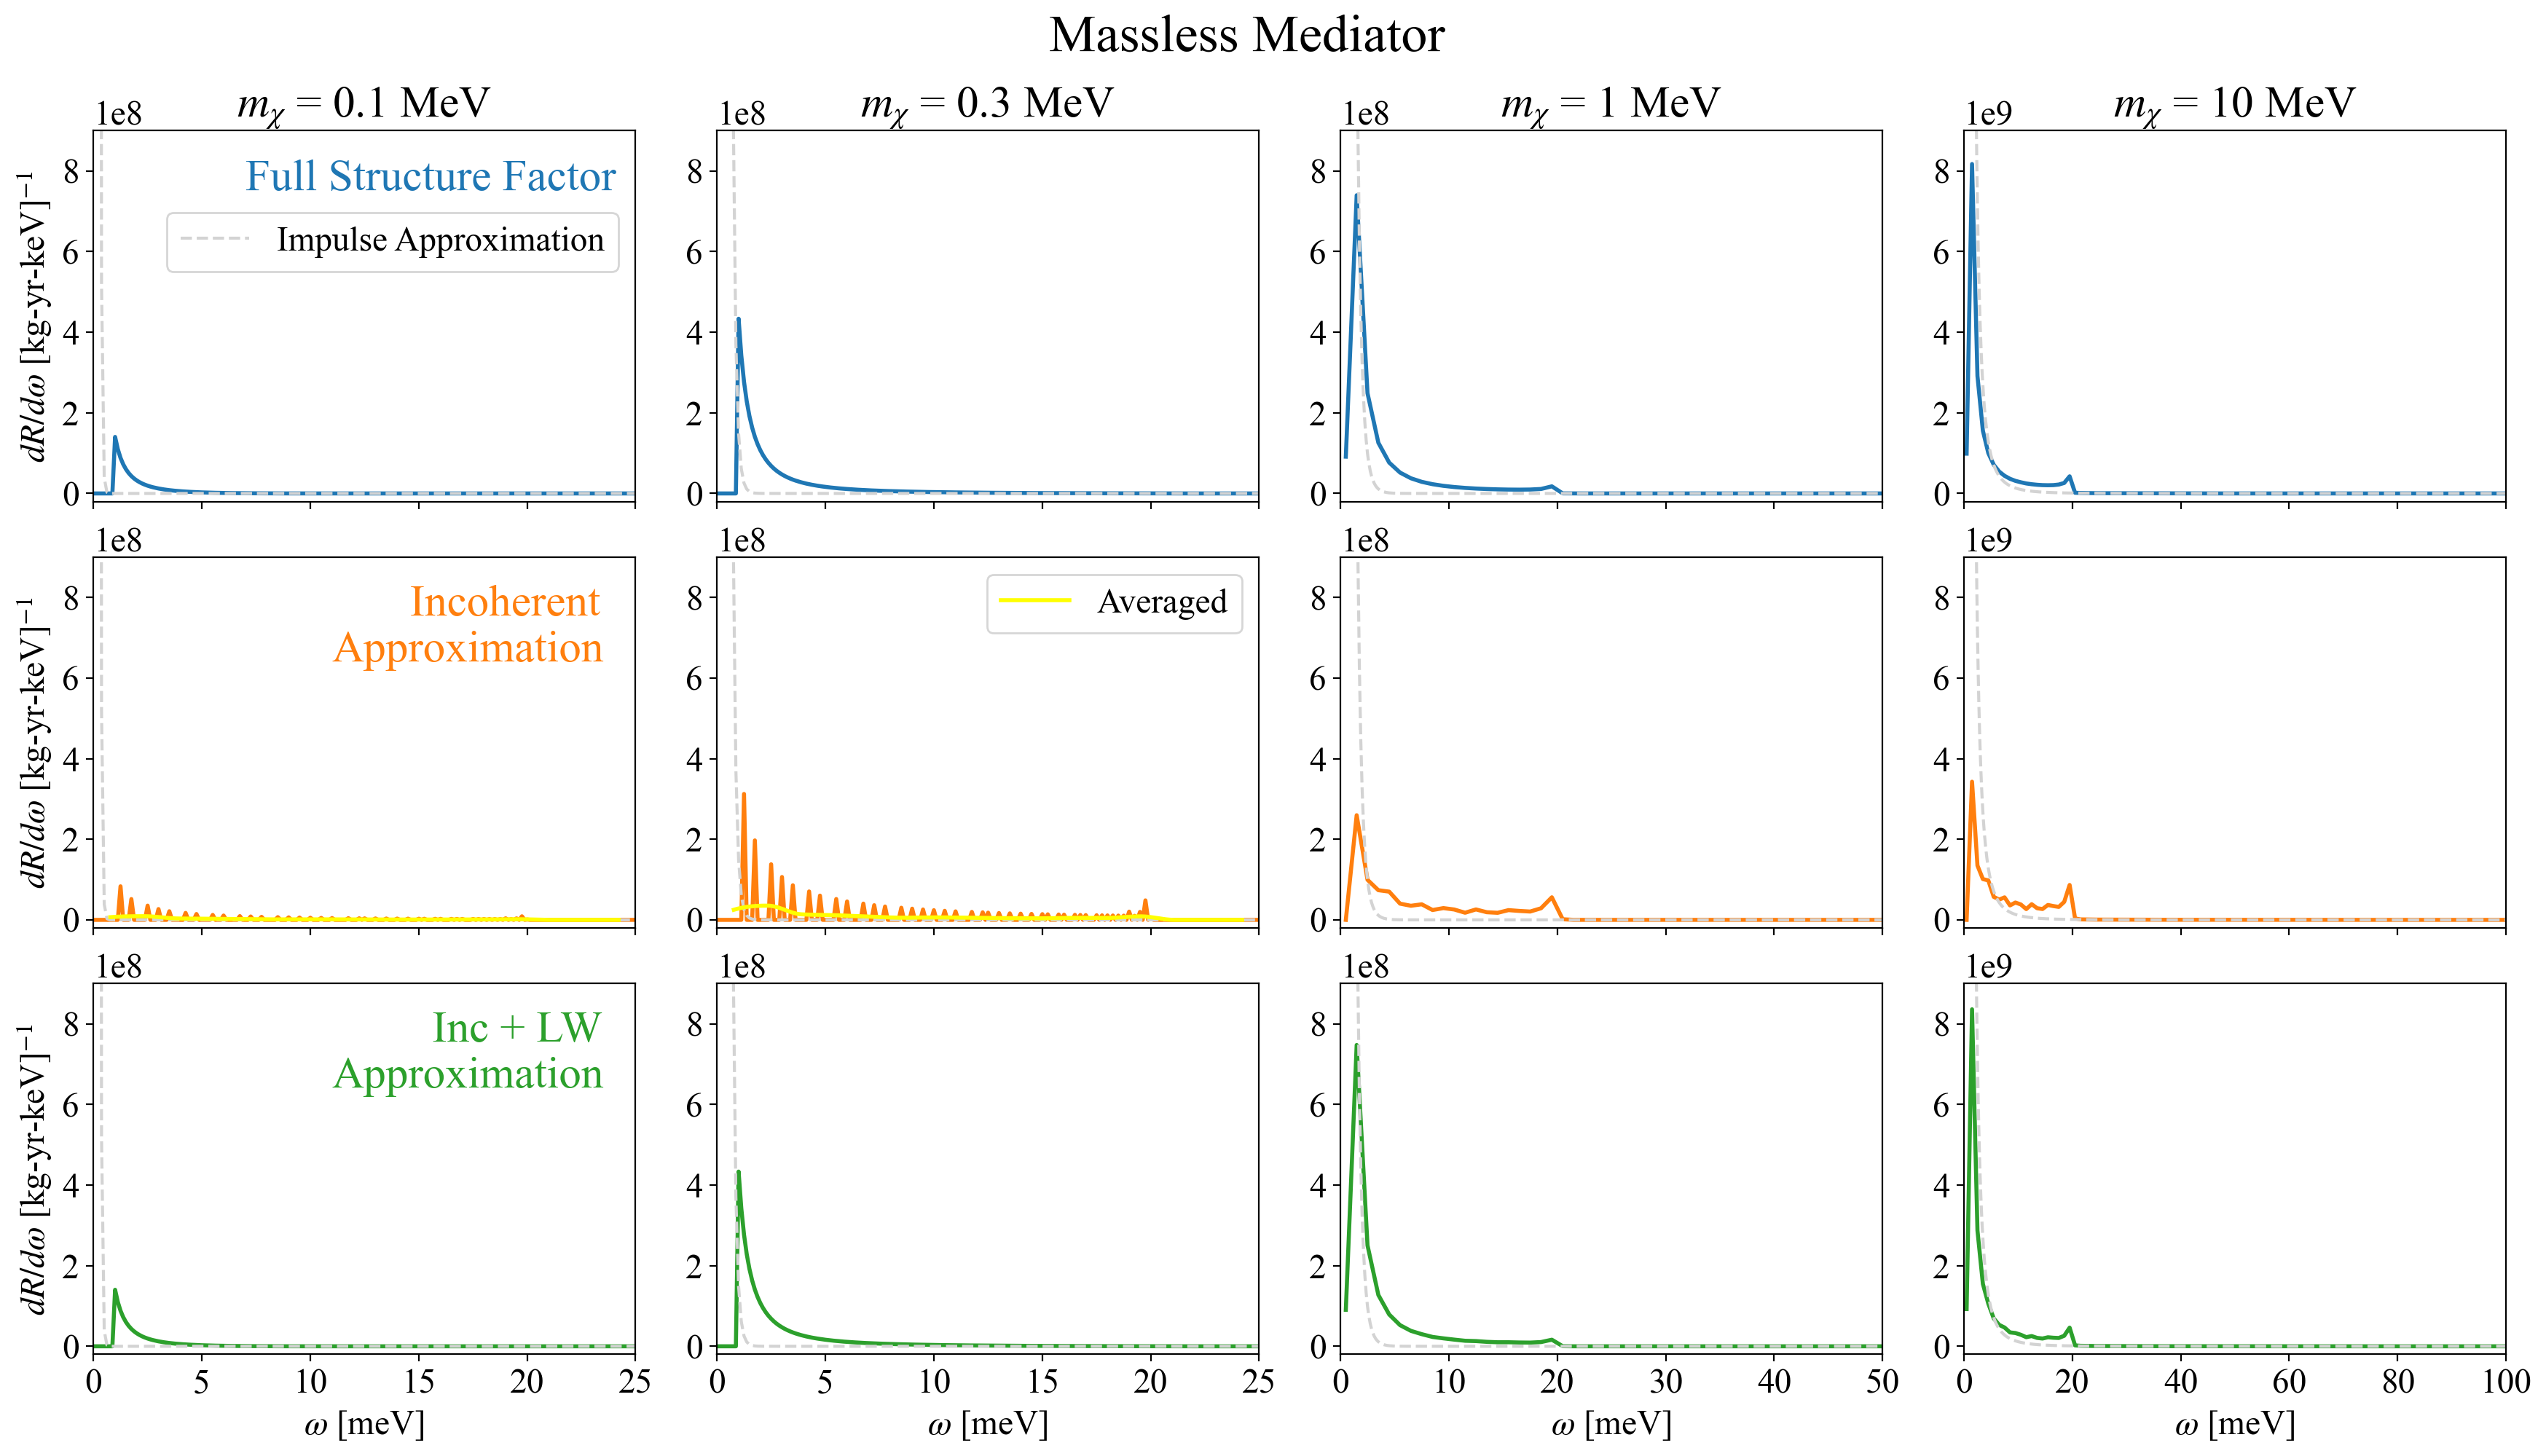

m_chi =   0.1 MeV   dR/domega range over the plotted window: 0.000e+00 to 1.403e+08
m_chi =   0.3 MeV   dR/domega range over the plotted window: 0.000e+00 to 4.335e+08
m_chi =     1 MeV   dR/domega range over the plotted window: 0.000e+00 to 1.467e+09
m_chi =    10 MeV   dR/domega range over the plotted window: 0.000e+00 to 1.667e+10


In [35]:
my_xmax_list = [25, 25, 50, 100]

# The massless-mediator form factor (q_ref/q)^4 strongly suppresses high q and
# enhances low q, so the y scale here bears no relation to the massive case.
# The old limits were
#     [(-2e6, 9e8), (-2e6, 9e8), (-2e6, 9e8), (-1.0e6, 4e9)]
# and they are certainly wrong now, so autoscale first (ylim_list=None), read
# off the actual ranges, then re-tune by hand if you want a fixed scale:
#
my_ylim_list = [
(-20e6, 9e8), (-20e6, 9e8), (-20e6, 9e8), (-200e6, 9e9)
]
# my_ylim_list = None

fig, axes = plot_rate_grid_3x4(
    dmmasslist=dmmasslist_4plot,
    omega_list=omega_list_nSite,
    row_data=[rates_full, rates_incoh, rates_inc_lw],
    dRdomega_impulse_tot=dRdomega_impulse_tot,
    xmax_list=my_xmax_list,
    ylim_list=my_ylim_list,
)
# fig.savefig("dRdomega_grid_3x4_masslessMediator.pdf", bbox_inches="tight")

# Print the plotted ranges so the limits above can be re-tuned from real numbers.
for _c, _m in enumerate(dmmasslist_4plot):
    _win = omega_list_nSite <= my_xmax_list[_c] * 1e-6
    _lo = min(np.nanmin(_r[_c][_win]) for _r in (rates_full, rates_incoh, rates_inc_lw))
    _hi = max(np.nanmax(_r[_c][_win]) for _r in (rates_full, rates_incoh, rates_inc_lw))
    print(f"m_chi = {_m/1e3:5g} MeV   dR/domega range over the plotted window: "
          f"{_lo:.3e} to {_hi:.3e}")


### Optional: single-panel cross-check

Compare the analytic single-phonon continuum against the smoothed numerical
incoherent rate for one mass.

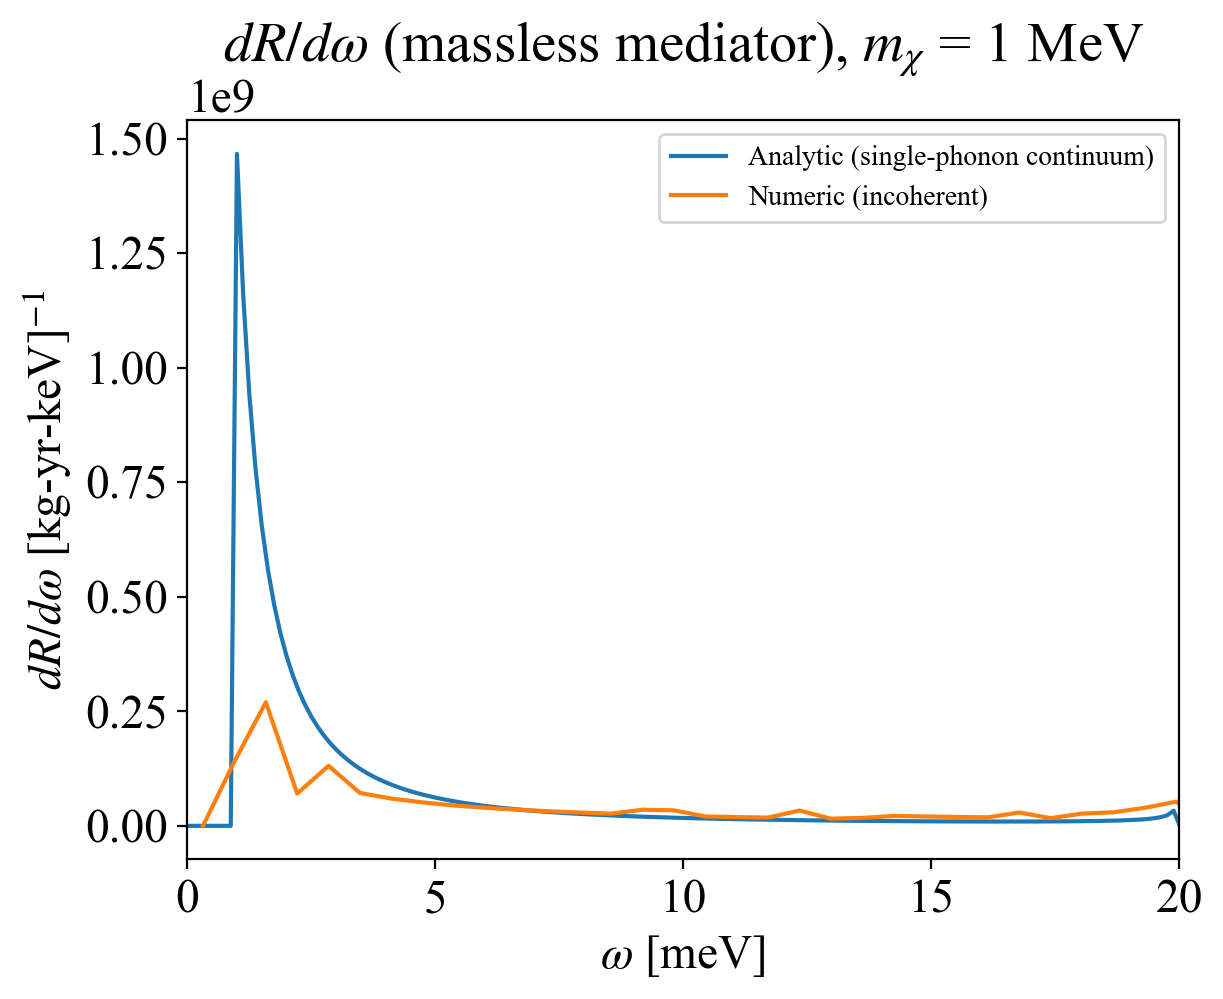

In [25]:
idx = 2   # which DM mass

plt.plot(omega_list_nSite * 1e6, drdomg_sp_continuum[idx], label="Analytic (single-phonon continuum)")
binned_omega, binned_rate = bin_arrays(omega_list_nSite, dRdomega_result_incoh_4plot[idx], 395)
plt.plot(binned_omega * 1e6, binned_rate, label="Numeric (incoherent)")
plt.xlim(0, 20)
# y autoscaled: the (q_ref/q)^4 form factor moves this by orders of magnitude,
# so the massive-mediator limit plt.ylim(-1e4, 0.5e7) no longer applies.
plt.legend(fontsize=10)
plt.title(rf"$dR/d\omega$ (massless mediator), $m_\chi$ = {dmmasslist_4plot[idx]/1e3:g} MeV")
plt.xlabel(r'$\omega$ [meV]')
plt.ylabel(r"$dR/d\omega$ [kg-yr-keV]$^{-1}$")
plt.show()
